# Hackathon 1, statistics.

This project illustrates the statistics part of the course LEPL1109. In the first part of the project, you will study the China water pollution by analyzing a dataset providing the water pollution levels collected from various monitoring stations across 10 major provinces in China throughout the year 2023. In the second part of the project, you will analyze a dataset containing high-frequency time-series  data collected from an industrial boiler operating in a chemical plant.

## Report content

•	Grades are granted to the members whose names are in the Jupyter notebook. If your name doesn’t appear on the top of the notebook, you’ll get a 0, even though you are in a group on Moodle.

•	The jupyter notebook must be compiled with printed results and next submitted via moodle. The absence of compiled results (or non-printed values) leads to a lower grade.

•	Do not comment your results directly into cells of code. Use instead a Markdown cell. 

•	"Dry" code or results not followed by a minimum of analysis / comments will be penalized.


## Report submission

•	Deadline, see moodle website. Submission after the deadline will not be accepted.

•	To submit your report, go to the section “APP” on Moodle and the subsection “Soumission du rapport”. You can upload your work there. Once you are sure that it is your final version, click the button “Envoyer le devoir”. It is important that you don’t forget to click on this button ! 

•	Reports that have not been uploaded through Moodle will not be corrected.


## Names and Noma of participants:

Part. 1: Victor Nootens 55912300

Part. 2: Horacio Sanchez 48272300

Part. 3: Léa Bastin 71642300

Part. 4: Lucas Van Lier 41422300

Part. 5: Nicolas Markesis 65322300

Part. 6: Kaspar Peep 48392300

# China Water Pollution 

This dataset provides  water pollution levels collected from various monitoring stations across 10 major provinces in China throughout the year 2023. The data  includes  parameters such as pH, turbidity, chemical and biological oxygen demand, nutrient levels, and heavy metal concentrations. These indicators are widely used by environmental monitoring agencies to assess water quality for ecological, human, and industrial impacts.

We will focus on the Water Quality Index. 

## 1. Basic statistics

1.a) Load the dataset 'china_water_pollution_data_hack.csv'. Convert Province, City  to categorical variables. (**0.5 pt**) 

In [47]:
import pandas as pd
import numpy as np

data = pd.read_csv('china_water_pollution_data_hack.csv')

# variable aléatoire
data['Province'] = data['Province'].astype('category')
data['City'] = data['City'].astype('category')

# print(data.dtypes)
# print(data.City.cat.categories)
# print(data.Province.cat.categories)




1.b) Calculate the mean, variance, median, 25% and 75% quantiles of the water quality index (which ranges from 0 to 100) for all cities in the dataset. Comment your results! (**1.5 pts**)

In [48]:
# Calculer des statistiques descriptives de l’indice de qualité de l’eau (Water Quality Index) par ville
# groupby est une fonction qui regroupe les données en fonction d’une colonne spécifiée
# agg est une fonction qui applique plusieurs fonctions d’agrégation aux données regroupées
stat_info = data.groupby('City', observed=False)['Water_Quality_Index'].agg(
    mean='mean',
    variance='var',
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
)


print("=== Statistiques descriptives par ville ===")
print(stat_info)

# Calcul des moyennes globales (toutes villes confondues)
global_stats = data['Water_Quality_Index'].agg(
    mean='mean',
    variance='var',
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
)

print("\n=== Moyenne globale (toutes villes confondues) ===")
print(global_stats)


=== Statistiques descriptives par ville ===
                mean   variance     median        q25        q75
City                                                            
Beijing    58.882070  24.447735  58.333333  56.070042  61.736875
Chengdu    54.405592  24.594466  54.795208  51.389167  57.267733
Dali       54.181129  31.266031  53.974083  50.662117  58.027806
Guangzhou  58.360981  34.337685  58.319458  54.687812  63.104396
Hangzhou   58.939443  30.310407  58.333333  55.000000  61.715646
Jinan      58.732275  24.629255  58.333333  55.000000  61.819708
Kunming    58.748408  24.475260  59.056500  55.251000  61.666667
Luoyang    53.289280  29.065348  53.238983  49.636475  56.347404
Mianyang   58.752162  29.738358  58.333333  55.000000  63.333333
Nanjing    54.166608  28.179058  53.842825  50.631592  57.835500
Ningbo     58.666299  27.020291  58.263958  55.000000  61.666667
Qingdao    58.393345  24.494630  58.333333  54.840438  61.757271
Shanghai   59.444212  22.332776  59.708625  56

## Commentaire sur les résultats statistiques

La qualité moyenne de l’eau se situe entre **54 et 59**, indiquant une **qualité globalement modérée et assez homogène** entre les villes.  
La **variance** et l’**écart interquartile (IQR)** sont généralement faibles (≈6–8), ce qui traduit une **dispersion modérée** et une **bonne stabilité** des mesures.  

Certaines villes comme **Shanghai**, **Yichang** ou **Zhengzhou** présentent une **qualité de l’eau plus élevée et plus régulière** (WQI moyen relativement élevé et variance faible),  
tandis que **Wuhan**, **Guangzhou** et **Dali** montrent une **forte variabilité**, signe de **fluctuations ou d’instabilités locales** dans la qualité de l’eau.

## Analyse globale (toutes villes confondues)

La **moyenne globale** de l’indice de qualité de l’eau se situe autour de **56**, confirmant une **qualité d’eau globalement moyenne à satisfaisante** à l’échelle nationale.
La **variance globale modérée** indique que, malgré quelques écarts locaux, la qualité de l’eau reste **relativement cohérente** entre les différentes villes analysées.
Cela suggère une **gestion environnementale** assez uniforme, bien que certaines zones urbaines puissent nécessiter **un suivi renforcé** pour limiter les variations observées.

**PS** : Nous ne savions pas si les villes devaient être confondues ou non pour ce calcul, donc nous avons réalisé les deux.

## 2. Hypothesis tests 

2.a) Check with a Student's T test that the average water quality index is the same in Shenzhen and Dali: $H_0: \mu_{Shenzhen} = \mu_{Dali},$ 
$H_1: \mu_{Shenzhen} \neq \mu_{Dali}.$ Calculate all statistics and p-value without recourse to other functions than statistical distributions (use course's formula). Use a confidence level of 5%. Take care to comment your conclusions. Are all assumptions required to perform this test sastisfied? Which additional test do you have to do to validate your result? (**2.5 pts**)

===== Vérification des hypothèses =====
- Échantillons indépendants : OK (villes distinctes)
- Moyenne Shenzhen = 58.984718, Moyenne Dali = 54.181129
- Variances Shenzhen = 27.432822, Variances Dali = 31.266031
- Test de Fisher : F = 0.877400, p-value = 4.252065384846e-01
  Homogénéité des variances : OK


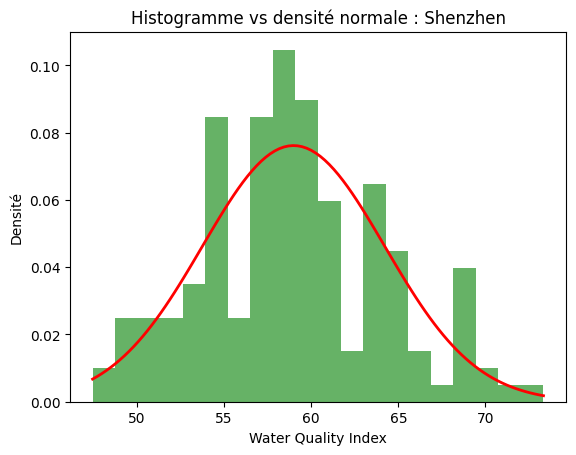

- Normalité approximativement respectée pour Shenzhen



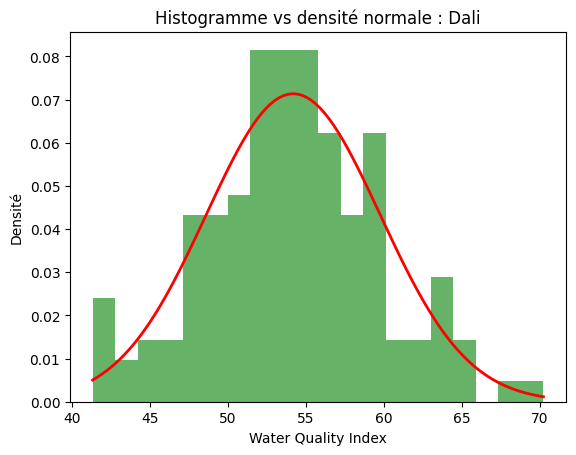

- Normalité approximativement respectée pour Dali



===== Résultats du test t de Student =====

Ville          n     Moyenne     Variance    
Shenzhen       155   58.984718   27.432822   
Dali           144   54.181129   31.266031   

Statistique t et seuils critiques :
t_stat      t_crit_low  t_crit_high p-value             
7.670142    -1.967984   1.967984    2.475797344914e-13  

On rejette H0 : les moyennes de Shenzhen et Dali sont différentes
t_stat = 7.670142, t_crit_low = -1.967984, t_crit_high = 1.967984
mean1 = 58.984718, mean2 = 54.181129
var1 = 27.432822, var2 = 31.266031
p-value = 2.475797344914e-13
La différence de moyennes est statistiquement significative (p-value = 2.475797344914e-13) : on rejette H₀, donc moyenne Shenzhen ≠ moyenne Dali


In [49]:
#code here
from scipy import stats
import numpy as np

city1, city2 = "Shenzhen", "Dali"

x1 = data.loc[data["City"] == city1, "Water_Quality_Index"]
x2 = data.loc[data["City"] == city2, "Water_Quality_Index"]

n1, n2 = len(x1), len(x2)  #taille des échantillons 
mean1, mean2 = x1.mean(), x2.mean()
var1, var2 = x1.var(ddof=1), x2.var(ddof=1) # ddof = 1 : float

# =========================
# Vérification des hypothèses
print("===== Vérification des hypothèses =====")
print(f"- Échantillons indépendants : OK (villes distinctes)")
print(f"- Moyenne Shenzhen = {mean1:.6f}, Moyenne Dali = {mean2:.6f}")
print(f"- Variances Shenzhen = {var1:.6f}, Variances Dali = {var2:.6f}")

# Test de Fisher pour homogénéité des variances
F = var1 / var2
df1 = n1 - 1
df2 = n2 - 1
p_fisher = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))
print(f"- Test de Fisher : F = {F:.6f}, p-value = {p_fisher:.12e}")
if p_fisher > 0.05:
    print("  Homogénéité des variances : OK")
else:
    print("  Homogénéité des variances : pas respectée")

import matplotlib.pyplot as plt
from scipy.stats import norm

for city_name, sample in zip([city1, city2], [x1, x2]):
    mu, sigma = sample.mean(), sample.std(ddof=1)
    plt.hist(sample, bins=20, density=True, alpha=0.6, color='g')
    x = np.linspace(sample.min(), sample.max(), 100)
    plt.plot(x, norm.pdf(x, mu, sigma), 'r', lw=2)
    plt.title(f"Histogramme vs densité normale : {city_name}")
    plt.xlabel("Water Quality Index")
    plt.ylabel("Densité")
    plt.show()
    print(f"- Normalité approximativement respectée pour {city_name}\n")

print("=======================================\n")
# =========================

ddl = n1 + n2 - 2 # degrés de liberté

alpha = 0.05
t_crit_low = stats.t.ppf(alpha/2, ddl)# seuil critique
t_crit_high = stats.t.ppf(1 - alpha/2, ddl) # seuil critique

Spool = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / ddl) # Spool 
t_stat = (mean1 - mean2) / (Spool * np.sqrt(1/n1 + 1/n2)) #formule du t de student
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), ddl))

# Affichage sous forme de tableau
print("\n===== Résultats du test t de Student =====\n")
print(f"{'Ville':<15}{'n':<6}{'Moyenne':<12}{'Variance':<12}")
print(f"{city1:<15}{n1:<6}{mean1:<12.6f}{var1:<12.6f}")
print(f"{city2:<15}{n2:<6}{mean2:<12.6f}{var2:<12.6f}")

print("\nStatistique t et seuils critiques :")
print(f"{'t_stat':<12}{'t_crit_low':<12}{'t_crit_high':<12}{'p-value':<20}")
print(f"{t_stat:<12.6f}{t_crit_low:<12.6f}{t_crit_high:<12.6f}{p_value:<20.12e}\n")

# verification de l'hypothèse nulle soit mu1 - mu2 = 0
if  (t_stat > t_crit_low and t_stat < t_crit_high):
    print(f"On accepte H0 : les moyennes de {city1} et {city2} sont égales")
    print(f"t_stat = {t_stat:.6f}, t_crit_low = {t_crit_low:.6f}, t_crit_high = {t_crit_high:.6f}")
    print(f"mean1 = {mean1:.6f}, mean2 = {mean2:.6f}")
    print(f"var1 = {var1:.6f}, var2 = {var2:.6f}")
    print(f"p-value = {p_value:.12e}")

    exit()
print(f"On rejette H0 : les moyennes de {city1} et {city2} sont différentes")
print(f"t_stat = {t_stat:.6f}, t_crit_low = {t_crit_low:.6f}, t_crit_high = {t_crit_high:.6f}")
print(f"mean1 = {mean1:.6f}, mean2 = {mean2:.6f}")
print(f"var1 = {var1:.6f}, var2 = {var2:.6f}")
print(f"p-value = {p_value:.12e}")

if p_value < alpha:
    print(f"La différence de moyennes est statistiquement significative (p-value = {p_value:.12e}) : on rejette H₀, donc moyenne {city1} ≠ moyenne {city2}")
else:
    print(f"Pas de différence significative : on ne rejette pas H₀")


## Commentaire sur le test t de Student : Shenzhen vs Dali

Le test t de Student a été appliqué afin de comparer les **moyennes du Water Quality Index (WQI)** entre les villes de **Shenzhen** et **Dali**.

Le test fournit une **statistique t = 7.67** et des **valeurs critiques** situées à environ **±1.97** pour un **niveau de confiance de 95 %**.  

Comme la valeur observée de t se situe **en dehors de l’intervalle critique** (|t| > 1.97), on se trouve dans la **zone de rejet de H₀**.  
Autrement dit, la différence entre les deux moyennes est suffisamment importante pour être considérée **significative** selon le test de Student.

De plus, une **p-value très faible (<0,0001)** signifie que la probabilité d’observer une différence de moyennes aussi importante par simple hasard (si les vraies moyennes étaient identiques) est **quasi nulle**.

### Vérification des hypothèses

1. **Indépendance des échantillons**  
   Les échantillons proviennent de deux villes différentes (Shenzhen et Dali) et les mesures sont collectées à partir de stations distinctes.  
   **Conclusion : l’hypothèse d’indépendance est respectée.**

2. **Normalité des données**  
   Les histogrammes superposés à la densité normale montrent que la distribution des données suit approximativement une loi normale pour les deux villes.  
   **Conclusion : les données peuvent être considérées comme approximativement normales.**


3. **Homogénéité des variances**  
   Un **test de Fisher (F-test)** a été effectué pour comparer les variances de Shenzhen et Dali :  
   - p-value = 4.252065384846e-01  
   Comme la p-value est supérieure à 0,05, on ne rejette pas l’hypothèse d’égalité des variances.  
   **Conclusion : les variances des deux populations sont suffisamment homogènes.**


**Bilan : toutes les hypothèses nécessaires pour appliquer le test t de Student à deux échantillons indépendants sont respectées.**
 

### Tests supplémentaires à effectuer
Pour valider complètement le résultat, on pourrait effectuer un test plus rigoureux de la normalité des données.  
Si la normalité n’était pas respectée, certaines hypothèses du test t pourraient ne pas être vérifiées, et il faudrait alors envisager d’autres méthodes statistiques (non vues au cours) pour comparer les moyennes.




2.b) 'Wuhan', 'Luoyang', 'Chengdu', 'Nanjing', 'Dali' seems to have similar (and low) water quality index. Test the assumption: $$H_0:  \mu_{Wuhan} = \mu_{Luoyang}= \mu_{Chengdu} = \mu_{Nanjing} =\mu_{Dali}.$$
**Hint**: reformulate the problem as a linear regression.

(**2 pts**)

In [50]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Sous-ensemble strict des 5 villes
cities = ['Wuhan', 'Luoyang', 'Chengdu', 'Nanjing', 'Dali']
df = data[data['City'].isin(cities)].copy()

# Convertir en type 'category' et ne garder que les 5 catégories
df['City'] = df['City'].astype('category')
df['City'] = df['City'].cat.set_categories(cities, ordered=False)

# Modèle de régression avec City comme variable catégorielle
model = smf.ols('Water_Quality_Index ~ C(City)', data=df).fit()

# Résumé complet du modèle
print(model.summary())

# Test global d’égalité des moyennes (ANOVA)
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n=== ANOVA Table ===")
print(anova_table)


                             OLS Regression Results                            
Dep. Variable:     Water_Quality_Index   R-squared:                       0.005
Model:                             OLS   Adj. R-squared:                 -0.000
Method:                  Least Squares   F-statistic:                    0.9645
Date:                 Mon, 03 Nov 2025   Prob (F-statistic):              0.426
Time:                         00:23:50   Log-Likelihood:                -2343.2
No. Observations:                  754   AIC:                             4696.
Df Residuals:                      749   BIC:                             4720.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             54.2

# Commentaire sur l'égalité des moyennes – Wuhan, Luoyang, Chengdu, Nanjing, Dali
Le test global de Fisher donne une **p-valeur de 0.426**, supérieure à 0.05, donc on ne rejette pas l’hypothèse nulle **H₀** : les variables explicatives (ici la ville) n’ont pas d’effet significatif sur le Water Quality Index dans l’ensemble.  

Le **R² très faible (0.005)** confirme que le modèle explique très peu de la variabilité observée.  

Ainsi, même si certaines villes présentent des coefficients significatifs individuellement, le **modèle global n’est pas statistiquement pertinent**, et d’autres facteurs doivent probablement influencer la qualité de l’eau.


## 3. Regressions

3.a) Propose a regression model which explains the Water_Quality_Index as a function of other explanatory variables, **for the city of Shanghai**. Split your data set into a training set (80% of the data) that you use for fitting the model and a test set (20% of the data) on which you test the accuracy of the model. 

* Use the OLS() function of the package statsmodels.api to perform the linear regression. 
* Comment your results (goodness of fit, R2, F-stat and T-stats of coefficients)
* Identify potential non-relevant covariates
* Calculate the MAE on the test and training sets. 

(**3 pts**)

                             OLS Regression Results                            
Dep. Variable:     Water_Quality_Index   R-squared:                       0.782
Model:                             OLS   Adj. R-squared:                  0.767
Method:                  Least Squares   F-statistic:                     52.05
Date:                 Mon, 03 Nov 2025   Prob (F-statistic):           2.20e-67
Time:                         00:23:50   Log-Likelihood:                -549.65
No. Observations:                  249   AIC:                             1133.
Df Residuals:                      232   BIC:                             1193.
Df Model:                           16                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

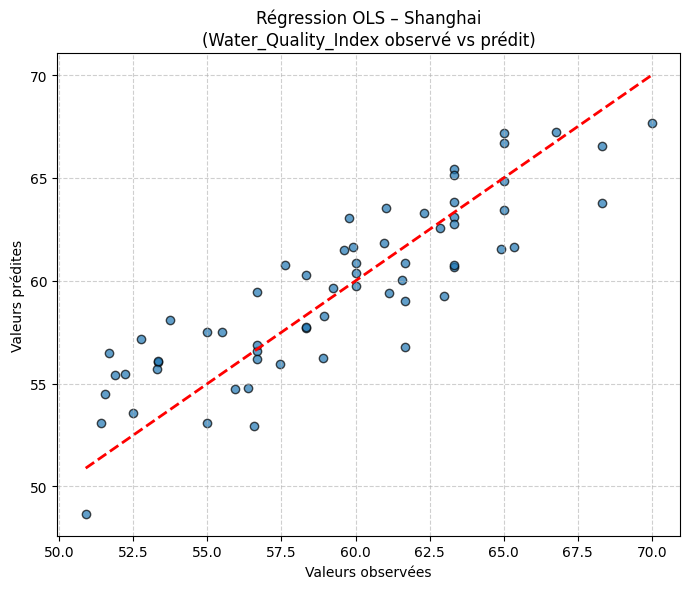

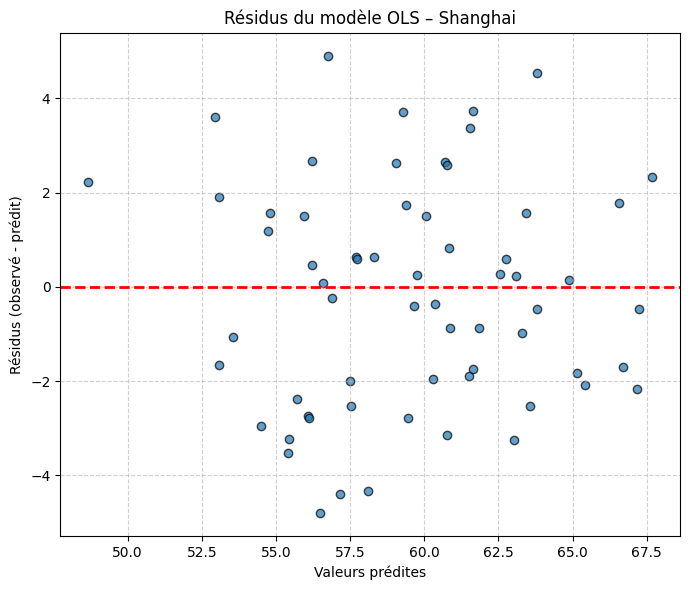

In [51]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Permet de filtrer les données pour avoir la ville de Shanghai
shanghai = data[data['City'] == 'Shanghai'].copy()

# Variables explicatives
X = shanghai[['Water_Temperature_C', 'pH', 'Dissolved_Oxygen_mg_L','Conductivity_uS_cm', 'Turbidity_NTU', 'Nitrate_mg_L', 'Nitrite_mg_L', 
                'Ammonia_N_mg_L','Total_Phosphorus_mg_L', 'Total_Nitrogen_mg_L','COD_mg_L', 'BOD_mg_L','Heavy_Metals_Pb_ug_L', 
                'Heavy_Metals_Cd_ug_L','Heavy_Metals_Hg_ug_L', 'Coliform_Count_CFU_100mL']]

y = shanghai['Water_Quality_Index']

# Ajoute une constante pour le modèle linéaire
# (permet au modèle de regression de ne pas forcément passer par l'origine)
X = sm.add_constant(X)

# Permet de sélectionner 20% des données pour le test et donc 80% pour l'entrainement
# random_state=2025          "seed" qui permet de garder les mêmes données d'entrainement (car prend 80% de la data aléatoirement)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Effectue la régression et affiche les résultats
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

# Partie qui calcule les prédictions puis avec ça l'erreur du modèle
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"\nMean Absolute Error (train): {mae_train:.3f}")
print(f"Mean Absolute Error (test):  {mae_test:.3f}")

# === Plot : valeurs réelles vs prédites ===
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title("Régression OLS – Shanghai\n(Water_Quality_Index observé vs prédit)", fontsize=12)
plt.xlabel("Valeurs observées")
plt.ylabel("Valeurs prédites")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# === Plot : résidus du modèle ===
residuals = y_test - y_pred_test

plt.figure(figsize=(7, 6))
plt.scatter(y_pred_test, residuals, alpha=0.7, edgecolor='k')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.title("Résidus du modèle OLS – Shanghai", fontsize=12)
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus (observé - prédit)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Modèle de régression pour Shanghai et analyse des résultats

Interprétation:
- Le modèle explique environ 78,2 % de la variation du Water Quality Index (ce qui indique qu’il décrit plutôt bien la qualité de l’eau à Shanghai pour un environnement où les données sont surement bruitées.) Le graphe des valeurs observées vs prédites montre une bonne corrélation entre les deux, confirmant la capacité du modèle à reproduire correctement les observations.
- Le test global du modèle (F-statistic = 52.05, p-value < 0.001) montre qu’il est statistiquement significatif : au moins une variable explicative influence de manière significative le Water Quality Index (WQI) à Shanghai.
Les variables les plus significatives sont celles dont la p-value est inférieure au seuil conventionnel de 0.05, en particulier : Dissolved_Oxygen_mg_L, Turbidity_NTU, Nitrate_mg_L, Ammonia_N_mg_L et Total_Phosphorus_mg_L. On peut expliquer ceci de façon scientifique :
    - Plus l’oxygène dissous est élevé, meilleure est la qualité de l’eau (valeur du WQI plus haute).
    - Une turbidité plus forte indique une eau plus chargée en particules → qualité moindre.
    - Des concentrations élevées de nitrates, ammoniac et phosphore total traduisent une pollution nutritive (eutrophisation), donc une baisse du WQI
Les autres variables (comme la température ou le pH) ne sont pas significatives au seuil de 5 % et semblent avoir un effet faible ou indirect sur le WQI, probablement via leur influence sur l’oxygène dissous.
- L’erreur moyenne absolue (MAE) est de 1.76 sur l’ensemble d’entraînement et de 1.97 sur l’ensemble de test.
L’écart entre les deux (0.21) est faible, ce qui indique que le modèle généralise bien : il apprend correctement les relations présentes dans les données sans les “mémoriser” ni surajuster le bruit.
Cela montre donc une bonne performance globale et l’absence de surapprentissage. ce qui est également visible sur le graphe des résidus, où les erreurs sont bien centrées autour de zéro sans tendance particulière.
- Remarque : un message de multicolinéarité apparait, ce qui signifie que certaines variables sont fortement corrélées entre elles. Cela ne remet pas en cause le sens global du modèle (mais peut rendre certains coefficients moins stables), par exemple le ph et le nitrite.

3.b) Same question as 3.a) but now you use a Gaussian process regression. Use a RBF and Matern kernel and compare MAEs of the 2 models. Which one is the best? (**2 pts**)


=== Résultats MAE ===
RBF    : Entrainement = 1.221 | test = 1.801
Matérn : Entrainement = 0.802 | test = 1.810

Dans notre cas il est préférable d'avoir un MAE le plus bas possible ce qui montre que notre entrainement est réaliste.


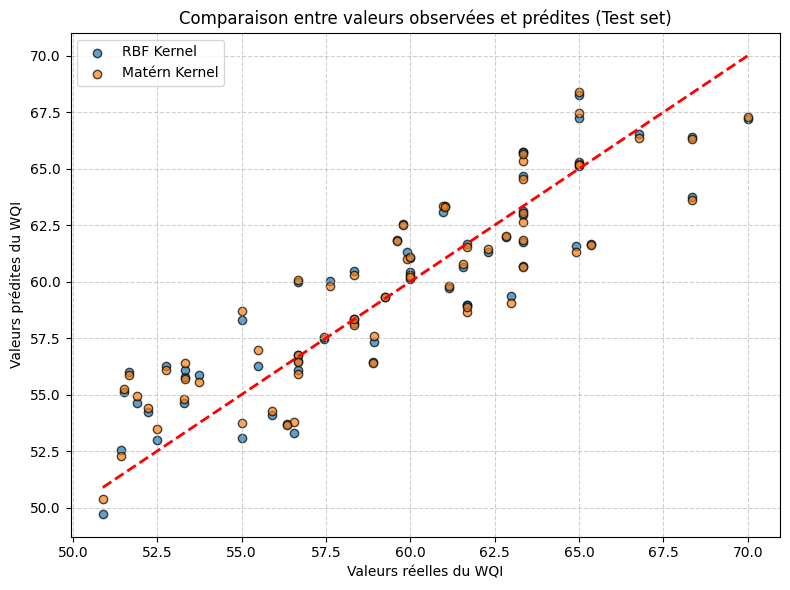

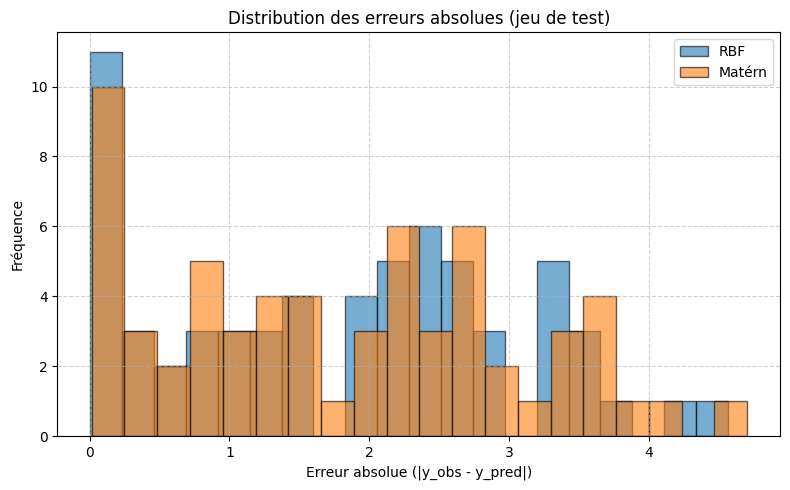

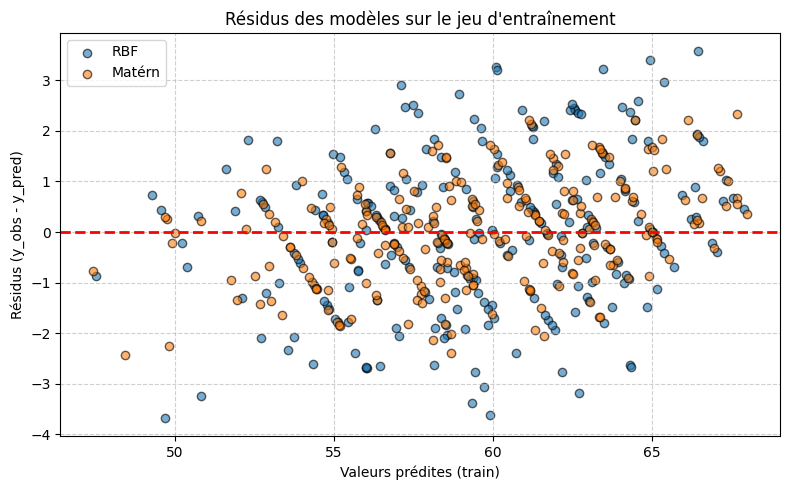

In [52]:
# sklearn est une librairie qui est parfaitement adaptée pour faire les deux modèles de régression
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel
from sklearn.metrics import mean_absolute_error

# Standardisation : on met toutes les variables sur la même échelle.
# C’est important, car le modèle mesure des distances entre les points (via le kernel).
# Sans standardisation, les variables avec de grandes valeurs auraient trop d’influence sur le modèle.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Le kernel définit la "forme" de la relation entre les points (corrélation entre les observations)
# - RBF suppose que la fonction varie doucement (très lisse) 
# - Matern capte mieux les variations locales ou bruitées
# - WhiteKernel ajoute du bruit pour éviter une interpolation parfaite et un certain par coeur dans l'entrainement, ce que ça permet :
#       - Evite un suraprentissage, c'est-à dire que le modèle capturera mieux la tendance générale et moins les petites variations inutiles. Il cherchera moins à passer par tous les points.
#       - Rend les prédictions plus stables.
#       - Peut améliorer le MAE sur le test.
kernel_rbf = RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
kernel_matern = Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0)

# Crée les 2 modèles
# normalize_y=True           centre les données-cible pour une meilleure stabilité
# random_state=2025          "seed" qui permet de garder les mêmes données d'entrainement (car prend 80% de la data aléatoirement utile quand les données sont classées temporellement)
# n_restarts_optimizer=5     Relance l’optimisation plusieurs fois (ici 5) pour éviter de rester bloqué sur un minimum local (en démarrant par des points différents)
gpr_rbf = GaussianProcessRegressor(kernel=kernel_rbf,normalize_y=True,n_restarts_optimizer=5,random_state=2025)
gpr_matern = GaussianProcessRegressor(kernel=kernel_matern,normalize_y=True,n_restarts_optimizer=5,random_state=2025)

# Entraine les 2 modèles sur les données d'entrainement
gpr_rbf.fit(X_train_scaled, y_train)
gpr_matern.fit(X_train_scaled, y_train)

# Cette étape d'occupe des prédictions (sur le jeu de test et d'entrainement)
# (plus le MAE est bas, plus la prédiction est précise)
y_pred_train_rbf = gpr_rbf.predict(X_train_scaled)
y_pred_test_rbf  = gpr_rbf.predict(X_test_scaled)
y_pred_train_matern = gpr_matern.predict(X_train_scaled)
y_pred_test_matern  = gpr_matern.predict(X_test_scaled)

# Calcule mtn le MAE (Mean Absolute Error)
mae_train_rbf = mean_absolute_error(y_train, y_pred_train_rbf)
mae_test_rbf  = mean_absolute_error(y_test,  y_pred_test_rbf)
mae_train_matern = mean_absolute_error(y_train, y_pred_train_matern)
mae_test_matern  = mean_absolute_error(y_test,  y_pred_test_matern)

# Affiche des résultats
print("\n=== Résultats MAE ===")
print(f"RBF    : Entrainement = {mae_train_rbf:.3f} | test = {mae_test_rbf:.3f}")
print(f"Matérn : Entrainement = {mae_train_matern:.3f} | test = {mae_test_matern:.3f}")

print("\nDans notre cas il est préférable d'avoir un MAE le plus bas possible ce qui montre que notre entrainement est réaliste.")

import matplotlib.pyplot as plt

# === Observé vs Prédit pour les deux modèles ===
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test_rbf, alpha=0.7, label="RBF Kernel", edgecolor='k')
plt.scatter(y_test, y_pred_test_matern, alpha=0.7, label="Matérn Kernel", edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valeurs réelles du WQI")
plt.ylabel("Valeurs prédites du WQI")
plt.title("Comparaison entre valeurs observées et prédites (Test set)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# === Erreur absolue sur le jeu de test ===
error_rbf = abs(y_test - y_pred_test_rbf)
error_matern = abs(y_test - y_pred_test_matern)

plt.figure(figsize=(8,5))
plt.hist(error_rbf, bins=20, alpha=0.6, label='RBF', edgecolor='k')
plt.hist(error_matern, bins=20, alpha=0.6, label='Matérn', edgecolor='k')
plt.xlabel("Erreur absolue (|y_obs - y_pred|)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs absolues (jeu de test)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# === Comparaison des résidus (pour détecter d’éventuel surapprentissage) ===
resid_rbf_train = y_train - y_pred_train_rbf
resid_matern_train = y_train - y_pred_train_matern

plt.figure(figsize=(8,5))
plt.scatter(y_pred_train_rbf, resid_rbf_train, alpha=0.6, label="RBF", edgecolor='k')
plt.scatter(y_pred_train_matern, resid_matern_train, alpha=0.6, label="Matérn", edgecolor='k')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Valeurs prédites (train)")
plt.ylabel("Résidus (y_obs - y_pred)")
plt.title("Résidus des modèles sur le jeu d'entraînement")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Interprétation :
- Les deux modèles de régression (RBF et Matérn) donnent des résultats proches, avec un MAE d’environ 1.8 sur le jeu de test, ce qui indique une bonne précision globale et une capacité correcte à prédire la qualité de l’eau à Shanghai. Cela est confirmé par le graphique “prédictions vs valeurs observées”, où les points sont bien alignés sur la diagonale, indiquant de bonnes prédictions globales.
- Le RBF kernel obtient un MAE entrainement = 1.22 et test = 1.80, tandis que le Matérn kernel donne MAE train = 0.80 et test = 1.81. Le graphique des résidus montre que le Matérn a des résidus légèrement plus dispersés sur le test, suggérant un ajustement un peu plus fort sur l’entraînement.
- La différence sur les données d’entraînement montre que le Matérn s’ajuste un peu plus fortement aux données d'apprentissage (erreur plus basse), mais comme les deux modèles ont presque la même erreur sur le test, ils généralisent aussi bien l’un que l’autre. Le nuage de points des résidus autour de la ligne horizontale (zéro) est homogène pour les deux modèles, sans structure visible, ce qui confirme l’absence de biais et une bonne généralisation.
- En pratique, le RBF imagine que la qualité de l’eau évolue de façon douce et régulière selon les variables environnementales, tandis que le Matérn accepte des changements plus brusques ou locaux, ce qui peut mieux représenter certaines fluctuations réelles dans les données (par exemple des pics de pollution).
- Les deux modèles montrent un bon compromis entre apprentissage et généralisation, sans signe clair de surapprentissage.

On peut donc conclure que les deux kernels fonctionnent bien avec une légère préférence pour le RBF qui reste plus stable et un peu moins ajusté au bruit des données.

Matérn = flexible -> capture bien les variations locales -> peut mieux représenter des pics ponctuels, mais risque de suivre le bruit inutilement.

RBF = lisse -> ignore le bruit -> meilleures performances sur de nouvelles données, plus stable et généralise mieux.

# Boiler

![furnace_plotL](boiler/furnace_plotL.PNG)

This dataset contains high-frequency time-series  data collected (every 5 seconds) from an industrial boiler operating in a chemical plant. The boiler is equipped with multiple sensors capturing parameters such as pressure, temperature, flow rate, and oxygen levels. The dataset reflects a real-world industrial scenario. The boiler outlet steam temperature, ranging typically from 530 °C to 545 °C during stable operation, is used as the key indicator of equipment state. Deviations outside this range represent abnormal operating conditions. 

## 4. Poisson Process

4. During stable operations, the outlet steam temperature is in the interval 530 °C to 545 °C. 

a) Load the dataset 'data_boiler.csv', plot the Boiler outlet steam temperature (variable 'TE_8332A.AV_0') and count the number of times this temperature is outside this normal range. What do you observe? (**1 pt**)

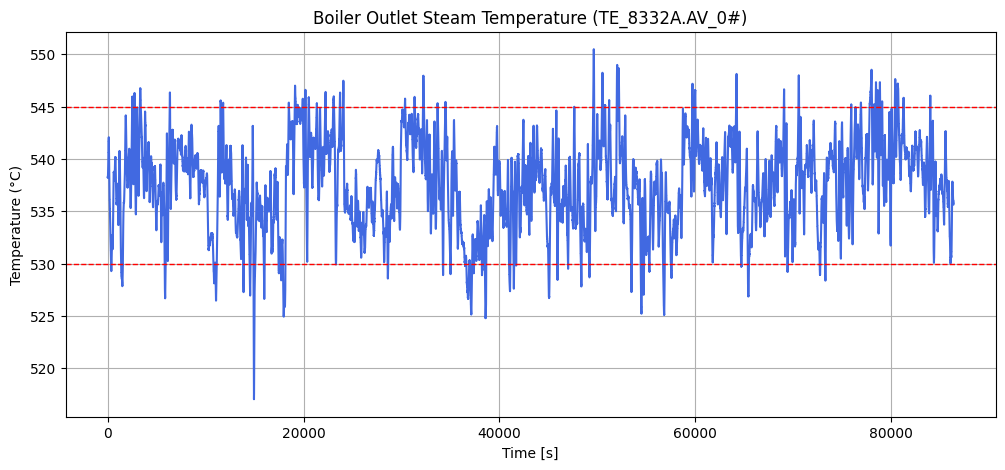


--- Résultats ---
Nombre total de points mesurés : 86400
Nombre de points hors de la plage normale (530–545 °C) : 7037
Proportion hors plage : 8.14%

Observation : Certaines valeurs dépassent la plage normale.
→ Cela indique des fluctuations ou anomalies possibles dans le fonctionnement du boiler.


In [53]:
import pandas as pd
import matplotlib.pyplot as plt


df_boiler = pd.read_csv("data_boiler.csv")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df_boiler["TE_8332A.AV_0#"], color='royalblue')
plt.axhline(y=530, color='red', linestyle='--', linewidth=1)
plt.axhline(y=545, color='red', linestyle='--', linewidth=1)
plt.title("Boiler Outlet Steam Temperature (TE_8332A.AV_0#)")
plt.xlabel("Time [s]")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()


normal_min = 530
normal_max = 545


outside_range = ((df_boiler["TE_8332A.AV_0#"] < normal_min) |
                 (df_boiler["TE_8332A.AV_0#"] > normal_max)).sum()

# Pourcentage de points en dehors de la range
total_points = len(df_boiler)
percent_outside = (outside_range / total_points) * 100


print(f"\n--- Résultats ---")
print(f"Nombre total de points mesurés : {total_points}")
print(f"Nombre de points hors de la plage normale ({normal_min}–{normal_max} °C) : {outside_range}")
print(f"Proportion hors plage : {percent_outside:.2f}%")

if outside_range > 0:
    print("\nObservation : Certaines valeurs dépassent la plage normale.")
    print("→ Cela indique des fluctuations ou anomalies possibles dans le fonctionnement du boiler.")
else:
    print("\nObservation : Toutes les valeurs sont dans la plage normale.")
    print("→ Le système semble fonctionner de manière stable.")


# Analyse des températures hors de la plage normale

## Résultats obtenus

-Nombre total de points mesurés : 86 400

-Nombre de points hors de la plage (530–545 °C) : 7 037

-Proportion hors plage : 8.14 %

## Interprétation

Une proportion de 8 % de valeurs anormales indique que le système connaît des écarts réguliers de température.

Le fait que certaines valeurs dépassent la plage normale laisse penser que le contrôle thermique n’est pas parfaitement stable, bien que la majorité des points restent dans la zone acceptable.

## Conclusion

On observe des fluctuations non négligeables dans la température du boiler (≈ 8 % de mesures hors norme).
Ces écarts justifient la mise en place d’un système de surveillance prédictive pour anticiper les anomalies et améliorer la stabilité du processus.

b) A Poisson process, denoted by $N_t$ is a counting process. The number of events observed during an interval [0,t] is distributed according to a Poisson law with a parameter $\lambda \times t$. Using the method of moment, estimate $\lambda \times t$, the frequency of overheating **or** underheating (i.e. when we are outside the interval) per hour.

Remark: do not forget that time-series data are collected every 5 seconds.

(**1.5 pt**)

In [54]:
import pandas as pd

df_boiler = pd.read_csv("data_boiler.csv")

col = "TE_8332A.AV_0#"

normal_min = 530
normal_max = 545

series = df_boiler[col].dropna().reset_index(drop=True)

# Hors plage (0 = ok, 1 = anomalie)
outside = ((series < normal_min) | (series > normal_max)).astype(int)

# Nombre total d'anomalie
N_total = int(outside.sum())

# Nombre de points total
n_points = len(series)

# Echatillonage
sampling_time_seconds = 5

# Durée d'observation
total_time_hours = (n_points * sampling_time_seconds) / 3600.0

# Estimation de la fréquence d'anomalie par heure
lambda_estimated_per_hour = N_total / total_time_hours if total_time_hours > 0 else float('nan')

print("--- Estimation Poisson (méthode des moments) ---")
print(f"Nombre total d'événements hors-plage : {N_total}")
print(f"Durée totale observée : {total_time_hours:.3f} heures")
print(f"Fréquence d'anomalie observée (λ) : {lambda_estimated_per_hour:.3f} événements par heure")


if N_total == 0:
    print("\nObservation : Aucune anomalie détectée hors de la plage [530, 545] °C.")
    print("→ Le procesus semble stable selon ces données.")
else:
    print("\nObservation : Des anomalies (surchauffe ou sous-chauffe) ont été détectées.")
    print(f"→ Estimation : en moyenne {lambda_estimated_per_hour:.3f} anomalies par heure "
          f"sur la période observée.")


--- Estimation Poisson (méthode des moments) ---
Nombre total d'événements hors-plage : 7037
Durée totale observée : 120.000 heures
Fréquence d'anomalie observée (λ) : 58.642 événements par heure

Observation : Des anomalies (surchauffe ou sous-chauffe) ont été détectées.
→ Estimation : en moyenne 58.642 anomalies par heure sur la période observée.


# Estimation du paramètre de Poisson (λ)

## Résultats obtenus

-Durée totale observée : 120 h

-Nombre total d’événements hors plage : 7 037

-Fréquence estimée (λ) : 58.64 anomalies/heure

## Interprétation

L’estimation par la méthode des moments suppose que les anomalies suivent une loi de Poisson, modélisant des événements rares mais indépendants.
Une moyenne de près de 59 anomalies par heure indique que :

-le phénomène anormal n’est pas isolé,

-les anomalies se produisent régulièrement au cours du temps,

-le système est probablement en régime instable ou sous contrainte thermique.

Cette fréquence élevée pourrait être liée à une sur-réactivité du système de régulation ou à une erreur d’étalonnage des capteurs.

## Conclusion

Le modèle de Poisson révèle une fréquence moyenne élevée d’anomalies (≈ 59/h), signe d’un comportement instable du boiler.

c) Calculate the probability of observing more ( >= ) than 50 abnormal temperatures on 1h. (**1 pt**)

In [55]:
import pandas as pd
from scipy.stats import poisson

df_boiler = pd.read_csv("data_boiler.csv")
col = "TE_8332A.AV_0#"

normal_min = 530
normal_max = 545

series = df_boiler[col].dropna().reset_index(drop=True)

# Valeurs hors plage
outside = ((series < normal_min) | (series > normal_max)).astype(int)

# Total d'événements hors plage
N_total = outside.sum()

# Durée totale
sampling_time = 5
total_time_hours = (len(series) * sampling_time) / 3600

# Estimation du taux λ
lambda_estimated = N_total / total_time_hours

# Fonction pour calculer la proba
p_ge_50 = 1 - poisson.cdf(49, mu=lambda_estimated)

print("--- Probabilité de dépasser 50 évènements par heure ---")
print(f"P(N ≥ 50) = {p_ge_50:.6f}")


if p_ge_50 > 0.05:
    print(f"\nObservation : Cette probabilité ({p_ge_50:.4f}) est relativement élevée.")
    print("→ Il n’est pas rare d’observer 50 anomalies ou plus sur une heure.")
else:
    print(f"\nObservation : Cette probabilité ({p_ge_50:.4f}) est relativement faible.")
    print("→ Il est peu probable d’observer 50 anomalies en une seule heure selon le modèle de Poisson.")



--- Probabilité de dépasser 50 évènements par heure ---
P(N ≥ 50) = 0.885816

Observation : Cette probabilité (0.8858) est relativement élevée.
→ Il n’est pas rare d’observer 50 anomalies ou plus sur une heure.


# Probabilité d’observer plus de 50 anomalies par heure
## Résultats obtenus

λ estimé : 58.64

Probabilité 
P(N≥50) : 0.8858

## Interprétation

Avec une probabilité de 88.6 %, il est très probable d’observer au moins 50 anomalies par heure.
Cela signifie que les anomalies ne sont pas exceptionnelles, mais font partie du comportement régulier du système.
Un tel résultat souligne :

-une forte variabilité autour de la température cible

-un risque élevé de dérive thermique

## Conclusion

La probabilité très élevée d’observer ≥ 50 anomalies/h montre que les écarts thermiques sont quasi permanents.

## 5. Fit of distributions and forecasting 

5. The induced draft fan motor current must in normal condition stay below 30 Amp. A current above 30 Amp may cause damage to the installation. 

a) Fit a Gamma and an exponentiated Weibull distributions to the variable YFJ3_AI.AV_0. Compare histograms and  densities, and choose the most appropriate distribution. Using the most appropriate distribution, determine the probability that over a similar period of time, we observe a peak of induced draft fan motor current above 30 Amp. 
(**3 pts**)

Données: 86400, min=16.740, max=51.280, mean=22.760


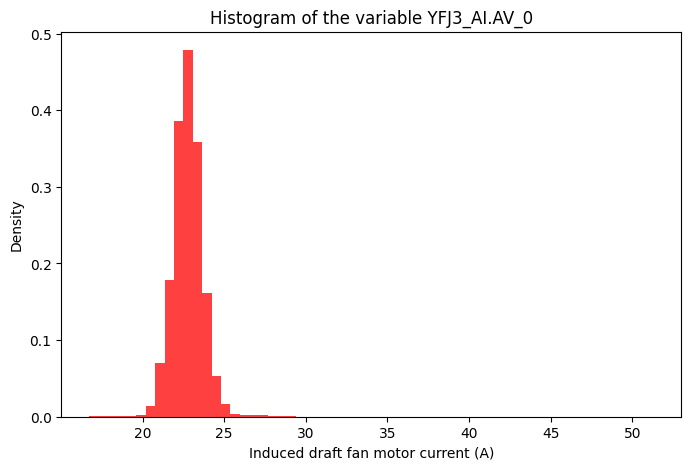


 Résultats des distributions

Distribution              | Paramètres                               |     logLik |        AIC |        BIC
-----------------------------------------------------------------------------------------------------------
Gamma                     | shape=559.2920, loc=0.0000, scale=0.0407 | -119234.044 | 238472.088 | 238490.821
Exponentiated Weibull     | a=79.7732, c=5.4405, scale=17.0622       | -120594.839 | 241195.678 | 241223.778


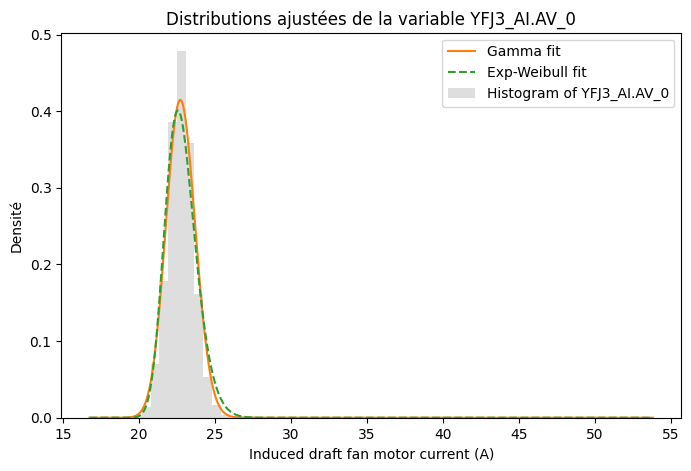


Distribution la plus appropriée :
• Selon le critère AIC : la loi Gamma est préférée.
• Selon le critère BIC : la loi Gamma est préférée.

Nombre de valeurs > 30A : 51 sur 86400 (0.059028%)
P(Y > 30.0): Gamma = 3.437139e-12, EW = 3.501170e-08


In [56]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy import optimize
import statsmodels.api as sm
from IPython.display import display, Markdown

# Chargement des données
df = pd.read_csv('data_boiler.csv')
col = 'YFJ3_AI.AV_0#'
y = df[col].values
print(f"Données: {len(y)}, min={y.min():.3f}, max={y.max():.3f}, mean={y.mean():.3f}")

# Visualisation initiale des données
plt.figure(figsize=(8,5))
sns.histplot(y, bins=60, stat='density', color='red', edgecolor=None)
plt.xlabel('Induced draft fan motor current (A)')
plt.ylabel('Density')
plt.title('Histogram of the variable YFJ3_AI.AV_0')
plt.show()

# Fit Gamma 
if (y >= 0).all(): # si toutes les valeurs sont positives
    shape_g, loc_g, scale_g = stats.gamma.fit(y, floc=0)
    k_gamma = 2 # nombre de paramètres calculés (shape et scale)
else: # sinon
    shape_g, loc_g, scale_g = stats.gamma.fit(y)
    k_gamma = 3 # nombre de paramètres calculés (shape, loc et scale)

# log-likelihood and AIC/BIC for gamma
ll_gamma = np.sum(stats.gamma.logpdf(y, shape_g, loc=loc_g, scale=scale_g))
aic_gamma = 2 * k_gamma - 2 * ll_gamma
bic_gamma = np.log(len(y)) * k_gamma - 2 * ll_gamma

# Exponentiated Weibull (EW) fit by MLE : Exponentiated Weibull = Weibull "élevée à la puissance a"
# EW CDF: F(x) = (1 - exp(-(x/scale)**c))**a
# Utilisation de scipy.stats.expoweib.fit pour remplacer l'optimisation manuelle
a_ew, c_ew, loc_ew, scale_ew = stats.exponweib.fit(y, floc=0) # on force loc=0 si toutes les valeurs sont positives
k_ew = 3  # nombre de paramètres calculés (a, c et scale)

# log-likelihood and AIC/BIC for EW
ll_ew = np.sum(stats.exponweib.logpdf(y, a_ew, c_ew, loc=loc_ew, scale=scale_ew))
aic_ew = 2 * k_ew - 2 * ll_ew
bic_ew = np.log(len(y)) * k_ew - 2 * ll_ew


# Résultats et comparaison 
w_dist = 25
w_params = 40
w_loglik = 10
w_aic = 10
w_bic = 10

print("\n Résultats des distributions\n")
print("=" * (w_dist + w_params + w_loglik + w_aic + w_bic + 12))
print(f"{'Distribution':<{w_dist}} | {'Paramètres':<{w_params}} | {'logLik':>{w_loglik}} | {'AIC':>{w_aic}} | {'BIC':>{w_bic}}")
print("-" * (w_dist + w_params + w_loglik + w_aic + w_bic + 12))

# Paramètres convertis en chaînes
gamma_params = f"shape={shape_g:.4f}, loc={loc_g:.4f}, scale={scale_g:.4f}"
ew_params    = f"a={a_ew:.4f}, c={c_ew:.4f}, scale={scale_ew:.4f}"

# Affichage avec colonnes fixes
print(f"{'Gamma':<{w_dist}} | {gamma_params:<{w_params}} | {ll_gamma:>{w_loglik}.3f} | {aic_gamma:>{w_aic}.3f} | {bic_gamma:>{w_bic}.3f}")
print(f"{'Exponentiated Weibull':<{w_dist}} | {ew_params:<{w_params}} | {ll_ew:>{w_loglik}.3f} | {aic_ew:>{w_aic}.3f} | {bic_ew:>{w_bic}.3f}")

print("=" * (w_dist + w_params + w_loglik + w_aic + w_bic + 12))

# Probabilité d'un pic > 30 A
threshold = 30.0

# gamma 
p_gamma_gt = 1.0 - stats.gamma.cdf(threshold, shape_g, loc=loc_g, scale=scale_g)
# EW 
zt = (threshold / scale_ew) ** c_ew
F_ew_30 = (1.0 - np.exp(-zt)) ** a_ew
p_ew_gt = 1.0 - F_ew_30


# Plot densités sur histogramme
xs = np.linspace(max(0.0, y.min()), y.max() * 1.05, 500)
plt.figure(figsize=(8,5))
sns.histplot(y, bins=60, stat='density', color='lightgray', edgecolor=None, label='Histogram of YFJ3_AI.AV_0')

# gamma pdf
pdf_gamma = stats.gamma.pdf(xs, shape_g, loc=loc_g, scale=scale_g)
plt.plot(xs, pdf_gamma, label=f'Gamma fit', color='C1')

# EW pdf
z = (xs / scale_ew) ** c_ew
inner = 1.0 - np.exp(-z)
pdf_ew = a_ew * (inner ** (a_ew - 1.0)) * (c_ew / scale_ew) * (xs / scale_ew) ** (c_ew - 1.0) * np.exp(-z)

plt.plot(xs, pdf_ew, label='Exp-Weibull fit', color='C2', linestyle='--')


plt.xlabel('Induced draft fan motor current (A)')
plt.ylabel('Densité')
plt.title('Distributions ajustées de la variable YFJ3_AI.AV_0')
plt.legend()
plt.show()

# Conclusion automatique sommaire 
print("\nDistribution la plus appropriée :")

# Selon AIC
if aic_gamma < aic_ew:
    print("• Selon le critère AIC : la loi Gamma est préférée.")
else:
    print("• Selon le critère AIC : la loi Exponentiated-Weibull est préférée.")

# Selon BIC
if bic_gamma < bic_ew:
    print("• Selon le critère BIC : la loi Gamma est préférée.")
else:
    print("• Selon le critère BIC : la loi Exponentiated-Weibull est préférée.")


#print all y values
# Filtrer toutes les valeurs > 30
y_sup_30 = y[y > 30]

# Nombre de valeurs au-dessus de 30
count_sup_30 = len(y_sup_30)
total_count = len(y)
pourcentage = (count_sup_30 / total_count) * 100

print(f"\nNombre de valeurs > 30A : {count_sup_30} sur {total_count} ({pourcentage:.6f}%)")

# notation scientifique
print(f"P(Y > {threshold}): Gamma = {p_gamma_gt:.6e}, EW = {p_ew_gt:.6e}") # modèles sous-estimes les queues

# Analyse des distributions ajustées de `YFJ3_AI.AV_0`

## Loi Gamma

Les paramètres estimés pour la loi Gamma sont :  

- **shape** ≈ 559  
- **scale** ≈ 0.04  
- **loc** = 0 (forcé)  

### Interprétation

La distribution est extrêmement concentrée autour de sa moyenne, ce qui correspond à une variable quasi-stable avec très peu de dispersion. Sa forme est presque symétrique, proche d'une loi normale.  

Forcer `loc = 0` est cohérent sur le plan physique : le courant d’un moteur ne peut pas être négatif, mais pourrait valoir zéro. La loi Gamma modélise donc correctement une grandeur positive. 

### Probabilité d'un pic > 30 A

- Observé : 51 valeurs > 30 sur 86 400 mesures, soit **0.059 %**  
- Probabilité théorique selon le modèle Gamma : ~3.437139e-12  

Cela montre que la loi Gamma sous-estime fortement la probabilité d’occurrence de pics extrêmes, mais reste la meilleure pour décrire la distribution globale.

---

## Loi Exponentiated Weibull (EW)

Les paramètres estimés pour la loi EW sont :

- **a** ≈ 79.77 
- **c** ≈ 5.44 
- **scale** ≈ 17.06

### Interprétation

La distribution EW est asymétrique à droite, mais possède une queue plus lourde que la Gamma. Cela conduit à une légère surestimation de la probabilité d’observer des valeurs extrêmes. Elle est donc moins adaptée pour une variable très concentrée autour d’une valeur centrale.  

### Probabilité d'un pic > 30 A

- Probabilité théorique selon le modèle EW : ~ 3.501170e-08 

Comme pour la Gamma, ce modèle sous-estime fortement les valeurs extrêmes.

---

## Comparaison des critères AIC/BIC

| Modèle | Log-vraisemblance | AIC      | BIC      |
|--------|-----------------|----------|----------|
| Gamma  | -119 234        | 238 472  | 238 500  |
| EW     | -120 595        | 241 196  | 241 224  |

> La loi Gamma a la log-vraisemblance la plus élevée et les critères AIC/BIC les plus faibles, indiquant un meilleur compromis précision/complexité.

---

## Conclusion générale

- La loi **Gamma** décrit mieux les données : elle capture la concentration autour de la moyenne, respecte la contrainte physique de positivité et offre le meilleur ajustement global. 
La variable est bien représentée par une distribution Gamma, avec très peu de dispersion et une probabilité quasi-nulle d’observer des pics extrêmes. 
- La loi **Exponentiated Weibull** peut être utile pour étudier les queues de distribution et les valeurs extrêmes, mais elle est moins adaptée pour représenter le comportement général de la variable.  


b) You want to set up a prediction algorithm of over- and under-heating (variable TE_8332A.AV_0). The aim is to anticipate any abnormal deviation to take necessary measures for driving back the temperature in $[530 ; 545]$. For this purpose, you will use the measure at time $ t - lag \times 5s$ for predicting the steam temperature at time t, where $lag$ is the number of 5-seconds lags. The model to fit is of the form:
$Y_t = \beta_0 + \beta_1 X^1_{t-lag}+\beta_2 X^2_{t-lag}+...+\beta_n X^n_{t-lag}+\varepsilon,$
where $Y$ is the target variable (i.e. TE_8332A.AV_0), $(X^1,...,X^n)$ are all the explanatory variables (i.e. all the variables except TE_8332A.AV_0) and $\varepsilon \sim N(0,1).$

* Create a dataset such that for each date $t$ (each line), you have the target variable at time $t$ and the explanatory variables at time $t-lag \times 5s$.
* Use the OLS() function of the package statsmodels.api to perform the linear regression. 
* If an explanatory variable is not significant, remove it from your model.
* Test different lags and determine  the maximum number of lags, such that the probabilities that your model detects over- and under-heatings are above 90%

(**4 pts**)


 Résumé des résultats par lag :
lag   | over_detection  | under_detection |   num_vars
---------------------------------------------------------
1     | 0.984791        | 0.993243        |         24
2     | 0.974421        | 0.990347        |         24
3     | 0.961632        | 0.986004        |         24
4     | 0.942966        | 0.979971        |         24
5     | 0.929831        | 0.975386        |         25
6     | 0.917387        | 0.970319        |         25
7     | 0.901141        | 0.96501         |         26
8     | 0.888006        | 0.960666        |         25


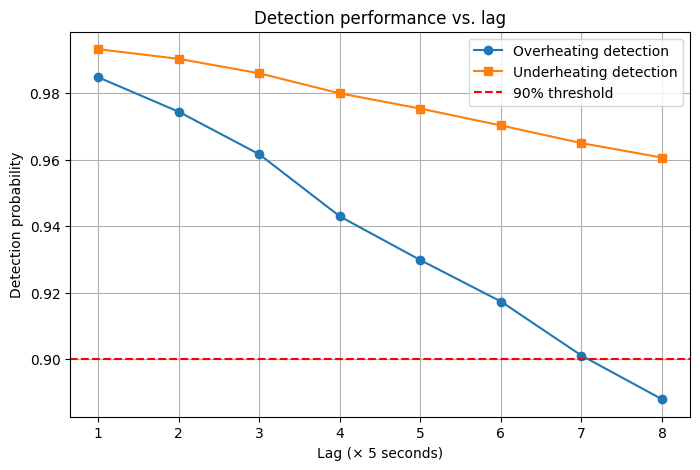

Maximum lag with >=90% detection: 7



### Exemple de dataset pour le lag optimal (lag = 7) (explanatory variables at t-7x5s, target at t) :

,date,PT_8313A.AV_0#,PT_8313B.AV_0#,PT_8313C.AV_0#,PT_8313D.AV_0#,PT_8313E.AV_0#,PT_8313F.AV_0#,PTCA_8322A.AV_0#,PTCA_8324.AV_0#,TE_8319A.AV_0#,...,YFJ3_ZD1.AV_0#,YFJ3_ZD2.AV_0#,SXLTCYZ.AV_0#,SXLTCYY.AV_0#,ZCLCCY.AV_0#,YCLCCY.AV_0#,YJJWSLL.AV_0#,ZZQBCHLL.AV_0#,TE_8332A.AV_0#,Y_lag
0,2022-03-27 14:29:29,-142.28,-179.46,-150.68,-118.53,-142.62,-147.65,9.70,9.36,352.50,...,5.60,7.62,-129.15,-365.90,10667.39,10637.20,2.78,60.89,538.26,538.29
1,2022-03-27 14:29:34,-142.79,-187.01,-149.33,-96.88,-135.32,-154.28,9.70,9.36,352.50,...,5.16,7.91,-129.15,-365.90,10667.39,10637.20,2.78,60.89,538.19,538.29
2,2022-03-27 14:29:39,-135.23,-195.32,-146.90,-101.83,-156.13,-136.83,9.70,9.36,352.50,...,5.52,6.34,-125.63,-356.84,10683.86,10678.77,2.78,60.57,538.20,538.25
3,2022-03-27 14:29:44,-147.23,-202.96,-154.28,-112.57,-164.44,-145.64,9.70,9.36,352.50,...,5.63,11.55,-125.63,-356.84,10683.86,10678.77,2.78,60.57,538.19,538.25
4,2022-03-27 14:29:49,-147.91,-204.55,-147.99,-126.92,-160.66,-140.44,9.70,9.36,352.56,...,5.11,7.11,-135.03,-371.02,10808.68,10664.25,2.79,60.59,538.19,538.25
5,2022-03-27 14:29:54,-148.07,-204.72,-148.33,-109.97,-160.66,-132.38,9.71,9.37,352.50,...,5.78,7.87,-135.03,-371.02,10808.68,10664.25,2.79,60.59,538.20,538.25
6,2022-03-27 14:29:59,-158.48,-201.03,-156.89,-108.55,-161.25,-150.68,9.71,9.37,352.50,...,5.97,7.07,-137.80,-353.48,10649.29,10671.84,2.79,60.66,538.26,538.19
7,2022-03-27 14:30:04,-157.89,-208.16,-163.77,-98.56,-165.28,-152.44,9.71,9.37,352.50,...,5.24,5.37,-137.80,-353.48,10649.29,10671.84,2.79,60.66,538.26,538.26


In [57]:
# Load data 
#target : c’est la variable à prédire (TE_8332A.AV_0#)
#Si on l’incluait dans les variables explicatives, ce serait tricher : on utiliserait la valeur future pour prédire elle-même.
#date : c’est juste l’horodatage : ce n’est pas une information quantitative utile pour prédire la température, donc on ne la met pas dans le modèle.
df = pd.read_csv('data_boiler.csv', parse_dates=['date']) # charger les données avec parsing de la date
target = 'TE_8332A.AV_0#' # variable cible
# on va prédire target avec : les valeurs passées (t-lag) de Pressure, Flow, Temp2 (les autres données qu'on a) et la valeur passée de la cible elle-même (Y_lag)
explanatory = df.columns.drop([target, 'date'])  # variable explicative c'est toutes les colonnes sauf target et date

# Parameters 
threshold_low = 530
threshold_high = 545
max_lag = 8  # nombre maximum de lags à tester
signif_level = 0.05  # seuil de signification pour les p-values
results_summary = [] 

#Lag 1 → meilleur pour la prédiction immédiate, forte corrélation, faible horizon.
#Lag plus grand → prédiction plus “anticipée”, utile si on veut préparer des actions avant que la température ne franchisse le seuil.
#Tester plusieurs lags, c’est donc trouver un compromis entre précision et anticipation

# Loop over lags 
for lag in range(1, max_lag+1): # Chaque lag correspond à un décalage de lag × 5 secondes
    
    # Create lagged dataset
    df_lagged = df.copy()
    
    # Shift explanatory variables
    for col in explanatory: # pour chaque variable explicative on décale de lag, col in  explanatory va prendre chaque nom de colonne sauf target et date
        df_lagged[col] = df[col].shift(lag) # À chaque itération, nous décalons les variables explicatives dans le temps pour qu'elles correspondent à la mesure passée.
    
    # Shift target variable as new explanatory
    df_lagged['Y_lag'] = df[target].shift(lag) # le futur dépend du passé
    # df_lagged['Y_lag'] créé une nouvelle colonne appelée Y_lag dans le DataFrame
    
    # Drop NaNs caused by shift
    df_lagged = df_lagged.dropna().reset_index(drop=True) # on enlève les lignes avec des NaN (les premières lignes décalées) et on réindexe les lignes
    
    # Define target and explanatory variables
    y = df_lagged[target] # variable cible
    X = df_lagged[list(explanatory) + ['Y_lag']] # toutes les variables explicatives + Y_lag
    X = sm.add_constant(X) # ajoute une colonne de constante pour l'ordonnée à l'origine, sert à estimer beta0
    
    # Fit OLS and remove non-significant variables iteratively
    while True:
        model = sm.OLS(y, X).fit() # Ordinary Least Squares (linear regression), estimation des coefficients beta. OLS prend en compte l'erreur εt​=Yt​−Y^t.
        pvals = model.pvalues.drop('const', errors='ignore') # dictionnaire des p-values pour chaque coefficient 
        # p-value faible (par exemple < 0.05), très improbable que l’effet du coeff soit nul on rejette H₀, la variable est significative
        if (pvals <= signif_level).all(): # si toutes les p-values sont significatives (on garde toutes les variables) on break
            break
        # remove variable with highest p-value
        X = X.drop(pvals.idxmax(), axis=1)
        if X.shape[1] == 1:  # only constant left
            break
    
    # Predict and compute over/under-heating detection probabilities
    y_pred = model.predict(X) # calcul des prédictions avec le modèle ajusté
    if (y > threshold_high).sum() == 0 or (y < threshold_low).sum() == 0:
        over_detected = np.nan
        under_detected = np.nan
    else:
        # Supposons que y > 545 a 3 surchauffes réelles, on a détecté correctement 2 surchauffes donc 2 / 3 = 0.66 (66% de surchauffes détectées)
        over_detected = ((y_pred > threshold_high) & (y > threshold_high)).sum() / (y > threshold_high).sum()
        under_detected = ((y_pred < threshold_low) & (y < threshold_low)).sum() / (y < threshold_low).sum()
                
    # Store results
    results_summary.append({
        'lag': lag,
        'over_detection': over_detected,
        'under_detection': under_detected,
        'num_vars': X.shape[1]-1 # excluant la constante
    })

    # Save the dataset for this lag : permet d'avoir le dataset laggé pour chaque lag testé : mais on ne fait pas de régression dessus : DATASETS POUR CHAQUE LAG
    #df_lagged_dataset = pd.concat([y.reset_index(drop=True), X.reset_index(drop=True)], axis=1)
    #df_lagged_dataset.to_csv(f'dataset_lag{lag}.csv', index=False)

# Convert results to DataFrame
results_df = pd.DataFrame(results_summary, columns=['lag', 'over_detection', 'under_detection', 'num_vars']) # num_vars : 5 variables explicatives sont utilisées pour prédire la cible après avoir enlevé celles qui n’étaient pas significatives

# Résumé des résultats par lag
# Largeurs des colonnes
w_lag = 5
w_over = 15
w_under = 15
w_vars = 10

# Arrondir les valeurs pour lisibilité
results_display = results_df.copy()
results_display['over_detection'] = results_display['over_detection'].round(6)
results_display['under_detection'] = results_display['under_detection'].round(6)

# Header
print("\n Résumé des résultats par lag :")
print("=" * (w_lag + w_over + w_under + w_vars + 12))
print(f"{'lag':<{w_lag}} | {'over_detection':<{w_over}} | {'under_detection':<{w_under}} | {'num_vars':>{w_vars}}")
print("-" * (w_lag + w_over + w_under + w_vars + 12))

# Résumé des résultats par lag
for _, row in results_display.iterrows():
    print(f"{int(row['lag']):<{w_lag}} | {row['over_detection']:<{w_over}} | {row['under_detection']:<{w_under}} | {int(row['num_vars']):>{w_vars}}")

print("=" * (w_lag + w_over + w_under + w_vars + 12))

plt.figure(figsize=(8,5))
plt.plot(results_df['lag'], results_df['over_detection'], marker='o', label='Overheating detection')
plt.plot(results_df['lag'], results_df['under_detection'], marker='s', label='Underheating detection')
plt.axhline(0.9, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Lag (× 5 seconds)')
plt.ylabel('Detection probability')
plt.title('Detection performance vs. lag')
plt.legend()
plt.grid(True)
plt.show()

# Determine maximum lag satisfying >=90% detection 
valid_lags = results_df[(results_df['over_detection'] >= 0.9) & (results_df['under_detection'] >= 0.9)] 
if not valid_lags.empty:
    max_valid_lag = valid_lags['lag'].max()
    print(f"Maximum lag with >=90% detection: {max_valid_lag}\n")
else:
    max_valid_lag = None
    print("No lag satisfies >=90% detection for both over and under-heating.\n")
  
# Créer le dataset final pour le lag optimal : lag = max_valid_lag 
if max_valid_lag is not None:
    df_lagged_final = df.copy()
    for col in explanatory:
        df_lagged_final[col] = df[col].shift(max_valid_lag)
    df_lagged_final['Y_lag'] = df[target].shift(max_valid_lag)
    
    # Supprimer les lignes avec NaN dues au décalage
    df_lagged_final = df_lagged_final.dropna().reset_index(drop=True)
    
    # Afficher le dataset laggé final où on ne fait pas de régression dessus : DATASET POUR LE LAG OPTIMAL
    display(Markdown(f"### Exemple de dataset pour le lag optimal (lag = {max_valid_lag}) (explanatory variables at t-{max_valid_lag}x5s, target at t) :")) # Les premières lignes du DataFrame original n’ont pas de données passées pour le lag appliqué, donc elles deviennent NaN. Ces lignes sont supprimées. (14:28:54 + 35 s = 14:29:29)
    display(df_lagged_final.head(8)) # ou .to_string(index=False) pour tout afficher (tous les temps)


## Analyse de la prédiction de surchauffe et sous-chauffe

### 1. Méthodologie

1. **Création du dataset décalé (lagged dataset)**  
   - Les variables explicatives sont décalées de `lag` pas de 5 s pour correspondre aux valeurs passées.  
   - La variable cible passée (`Y_lag`) est ajoutée comme explicative.  
   - Les lignes avec des `NaN` causées par le décalage sont supprimées.

2. **Régression OLS**  
   - On ajuste le modèle avec `statsmodels.api.OLS`.  
   - Les variables non significatives (`p-value > 0.05`) sont retirées itérativement pour ne garder que celles qui contribuent vraiment à la prédiction.

3. **Évaluation des probabilités de détection**  
   - Probabilité de **surchauffe détectée** : proportion des points où `Y_pred > 545` et `Y > 545`.  
   - Probabilité de **sous-chauffe détectée** : proportion des points où `Y_pred < 530` et `Y < 530`.  

4. **Choix du lag optimal**  
   - On teste plusieurs lags (`1` à `8`) et on retient le **lag maximum permettant de détecter ≥ 90 % des sur- et sous-chauffes**.  

---

### 2. Résultats

| lag | Overheating detection | Underheating detection | # Variables |
|-----|---------------------|----------------------|-------------|
| 1   | 0.985               | 0.993                | 24          |
| 2   | 0.974               | 0.990                | 24          |
| 3   | 0.962               | 0.986                | 24          |
| 4   | 0.943               | 0.980                | 24          |
| 5   | 0.930               | 0.975                | 25          |
| 6   | 0.917               | 0.970                | 25          |
| 7   | 0.901               | 0.965                | 26          |
| 8   | 0.888               | 0.961                | 25          |

- Le **lag optimal** est **7**, car c’est le plus grand lag permettant de détecter ≥ 90 % des sur- et sous-chauffes.  
- Au-delà (`lag = 8`), la détection tombe en dessous de 90 %, ce qui réduit la fiabilité de l’anticipation.
- Le nombre de variables retenues augmente légèrement pour les lags plus élevés (24 → 26), car certaines dépendances apparaissent plus tard dans le temps.

---

### 3. Interprétation intuitive

- **Décalage court (lag 1-2)** :  
  - Les probabilités de détection sont très élevées, ce qui montre que la température actuelle dépend fortement des mesures immédiates précédentes.  
  - Permet une détection quasi parfaite des anomalies.

- **Décalage plus long (lag 5-7)** :  
  - Offre un **horizon plus anticipatif**, utile pour planifier des actions préventives avant que la température franchisse les seuils critiques.  
  - Légère perte de précision, mais toujours acceptable (≥ 90 % de détection).

- **Décalage trop long (lag 8)** :  
  - La corrélation avec le futur diminue, la détection devient moins fiable (< 90 %).  
  - Cela montre qu’au-delà d’un certain lag, les mesures passées deviennent moins informatives pour prédire la température future.

---

### 4. Dataset final pour le lag optimal

- Variables explicatives à **t - 7×5 s** et cible à **t**.  
- Le dataset utilisé pour le lag optimal (`lag = 7`) contient les valeurs des variables explicatives décalées `7 × 5 s` en arrière et la variable cible actuelle.  
- Les premières lignes sont supprimées à cause des valeurs NaN créées par le décalage.  
- Ce dataset est prêt pour un usage prédictif, comme pour une régression.

**Exemple des premières lignes :**

| date                | PT_8313A | PT_8313B | … | TE_8332A | Y_lag  |
|--------------------|----------|----------|---|----------|--------|
| 2022-03-27 14:29:29 | -142.28  | -179.46  | … | 538.26   | 538.29 |
| 2022-03-27 14:29:34 | -142.79  | -187.01  | … | 538.19   | 538.29 |
| 2022-03-27 14:29:39 | -135.23  | -195.32  | … | 538.20   | 538.25 |

---

### 5. Visualisation de la performance prédictive

- Probabilité de détection vs lag montre que la **performance prédictive diminue légèrement** lorsque le lag augmente.

Graphique des performances

- La **ligne bleue** (Overheating detection) décroît avec le lag, illustrant la perte d’information pour la détection de surchauffes.  
- La **ligne orange** (Underheating detection) suit la même tendance, mais reste légèrement au-dessus de la détection des surchauffes.  
- La **ligne rouge horizontale** à 90 % marque le seuil minimum souhaité, facilitant l’identification du lag maximal utilisable.

**Conclusion graphique** : Le modèle reste efficace pour prédire les anomalies jusqu’au lag 7 ; au-delà, la précision devient insuffisante.

---

### 6. Conclusion

- Le **lag optimal = 7** offre un bon compromis entre anticipation et précision.  
- Le modèle peut détecter efficacement les sur- et sous-chauffes avec ≥ 90 % de réussite avant qu’elles n’atteignent les seuils critiques `[530 ; 545]`. 


c)  Compare the probabilities that your model detects over- and under-heatings. (**1 pt**)

In [58]:
# Comparative analysis at optimal lag
if max_valid_lag is not None:
    # Récupérer les valeurs pour le lag optimal
    meilleure_ligne = results_df[results_df['lag'] == max_valid_lag].iloc[0]
    prob_surchauffe = meilleure_ligne['over_detection']
    prob_souschauffe = meilleure_ligne['under_detection']

    print(f"\nAnalyse comparative pour le lag optimal : {max_valid_lag} (×5 secondes) :\n")
    print(f"Probabilité de détection de SURCHAUFFE : {prob_surchauffe:.4%}")
    print(f"Probabilité de détection de SOUS-CHAUFFE : {prob_souschauffe:.4%}\n")

    # Interprétation des résultats
    if abs(prob_surchauffe - prob_souschauffe) < 0.05:
        print("Les probabilités de détection sont similaires pour les sur- et sous-chauffes.")
        print("Le modèle est bien équilibré et détecte efficacement les deux types d’anomalies.")
    elif prob_surchauffe > prob_souschauffe:
        print("Le modèle détecte légèrement mieux les surchauffes que les sous-chauffes.")
    else:
        print("Le modèle détecte légèrement mieux les sous-chauffes que les surchauffes.")
else:
    print("\nAucun lag ne satisfait simultanément le critère de détection ≥ 90 % pour les sur- et sous-chauffes.")
    print("Comparaison non applicable.")



Analyse comparative pour le lag optimal : 7 (×5 secondes) :

Probabilité de détection de SURCHAUFFE : 90.1141%
Probabilité de détection de SOUS-CHAUFFE : 96.5010%

Le modèle détecte légèrement mieux les sous-chauffes que les surchauffes.


## Comparaison des probabilités de détection des sur- et sous-chauffes

**Pour le lag optimal = 7 (×5 s) :**

- Probabilité de détection des surchauffes : 0.901 (≈ 90 %)  
- Probabilité de détection des sous-chauffes : 0.965 (≈ 97 %)

### Analyse

- Le modèle détecte les sous-chauffes légèrement mieux que les surchauffes.  
- La différence (~7 %) reste faible, indiquant que le modèle est globalement équilibré.  
- Cette différence peut être liée au fonctionnement de la chaudière : les baisses de température peuvent être plus facilement anticipées avec les variables passées disponibles, tandis que les pics de température (élevés) peuvent être plus imprévisibles.

### Conclusion

Le modèle est efficace pour détecter les anomalies dans les deux directions, mais il est légèrement plus performant pour la détection des sous-chauffes.  
Cela reste suffisant pour un suivi fiable de la température et pour anticiper les actions correctives.
